# Contest Notebook: Artificial Neural Networks  
## Architecture, Forward Pass, and Backpropagation

Welcome to a **high-difficulty coding contest notebook** for Artificial Neural Networks.

This notebook is designed to test whether you truly understand:

1. **Artificial Neural Architectures**
2. **Training Neural Networks**
   - Forward pass: tensor operations
   - Backward pass: backpropagation

## Submitted by:
1. Abelardo, Aasen Sofia P.
2. Aquino, Matthew Benedict U.
3. Balingit, Den Mar F.
4. Gumban, Joevanni Paulo T.

## Contest Rules

- This is a **from-scratch** implementation challenge.
- Use **NumPy only** for neural-network computation.
- **Do not** use PyTorch, TensorFlow, JAX, Keras, scikit-learn neural network classes, or automatic differentiation.
- You must write both:
  - **code**, and
  - **mathematical / conceptual explanations** in new Markdown cells where instructed.
- Public tests are included, but passing them does **not** guarantee full credit.
- Hidden checks used by the instructor may evaluate:
  - vectorization,
  - correctness,
  - numerical stability,
  - explanation quality,
  - code clarity.

## Deliverables inside this notebook

You must complete all required `TODO` regions and add your explanations in Markdown cells below the prompts.

## Difficulty Notice

This notebook is intentionally difficult. It is designed like a **challenge game / contest**.  
The first student to complete it **correctly** may receive additional points, subject to instructor verification.

## Allowed tools

You may use:

- `numpy`
- `matplotlib` for plots only
- Python standard library

You may **not** use:

- `torch`, `tensorflow`, `keras`, `jax`
- automatic differentiation
- high-level neural-network libraries
- copied internet solutions

## Suggested workflow

1. Complete the architecture questions first.
2. Implement the forward pass carefully.
3. Implement the backward pass and verify with gradient checking.
4. Implement the optimizer and training loop.
5. Attempt the boss-level bonus section only after the required tasks work.

---

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

np.set_printoptions(precision=5, suppress=True)
GLOBAL_SEED = 7
rng = np.random.default_rng(GLOBAL_SEED)

def set_seed(seed=7):
    np.random.seed(seed)
    return np.random.default_rng(seed)

rng = set_seed(GLOBAL_SEED)
print("Environment ready.")

Environment ready.


In [38]:
# Helper datasets and utilities
def make_xor(n_per_quadrant=80, noise=0.10, seed=7):
    rng = np.random.default_rng(seed)
    centers = np.array([
        [-1.0, -1.0],
        [-1.0,  1.0],
        [ 1.0, -1.0],
        [ 1.0,  1.0]
    ])
    labels = np.array([0, 1, 1, 0])  # XOR pattern
    X_parts, y_parts = [], []
    for c, lab in zip(centers, labels):
        X_parts.append(c + noise * rng.standard_normal((n_per_quadrant, 2)))
        y_parts.append(np.full(n_per_quadrant, lab, dtype=int))
    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

def make_spiral(points_per_class=120, classes=3, noise=0.20, seed=7):
    rng = np.random.default_rng(seed)
    X = np.zeros((points_per_class * classes, 2))
    y = np.zeros(points_per_class * classes, dtype=int)
    for j in range(classes):
        ix = range(points_per_class * j, points_per_class * (j + 1))
        r = np.linspace(0.0, 1, points_per_class)
        t = np.linspace(j * 4, (j + 1) * 4, points_per_class) + rng.standard_normal(points_per_class) * noise
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = j
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

def train_val_split(X, y, val_fraction=0.20, seed=7):
    rng = np.random.default_rng(seed)
    n = len(X)
    idx = rng.permutation(n)
    n_val = int(round(n * val_fraction))
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]
    return X[train_idx], X[val_idx], y[train_idx], y[val_idx]

def accuracy_from_probs(probs, y_true):
    preds = np.argmax(probs, axis=1)
    return np.mean(preds == y_true)

def plot_2d_dataset(X, y, title="dataset"):
    plt.figure(figsize=(5, 4))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

## Challenge 0 — One-hot encoding and tensor discipline

Before building a neural network, confirm that you understand shape conventions.

### Task
Implement `one_hot(y, num_classes)` such that:

- input: `y` has shape `(N,)`
- output: matrix has shape `(N, C)`
- row `i` contains a `1` at the true class and `0` elsewhere

### Constraints
- No Python loops over samples
- Must be vectorized

After the code cell, add a **Markdown explanation** answering:

1. Why is one-hot encoding useful for multi-class classification?
2. Why does shape consistency matter in the forward and backward pass?

In [39]:
def one_hot(y, num_classes):
    y = np.asarray(y, dtype=int).ravel()
    Y = np.zeros((y.shape[0], num_classes), dtype=float)
    Y[np.arange(y.shape[0]), y] = 1.0
    return Y

In [40]:
# Public tests for Challenge 0
y_small = np.array([2, 0, 1, 2])
Y_small = one_hot(y_small, 3)

assert isinstance(Y_small, np.ndarray), "Output must be a NumPy array."
assert Y_small.shape == (4, 3), f"Expected shape (4, 3), got {Y_small.shape}"
assert np.allclose(Y_small.sum(axis=1), 1), "Each row must sum to 1."
assert np.array_equal(np.argmax(Y_small, axis=1), y_small), "Argmax of one-hot rows should recover labels."

print("Challenge 0 public tests passed.")

Challenge 0 public tests passed.


### Your written response for Challenge 0

Add a **new Markdown cell below this one** and explain your answers clearly.

### Challenge 0 Response

1. **Why one-hot encoding is useful for multi-class classification**  
One-hot encoding turns each class label into a vector target with exactly one positive class and the rest zero. This makes the target compatible with softmax outputs, so the model can learn a probability distribution over classes and minimize cross-entropy directly.

2. **Why shape consistency matters in forward and backward passes**  
Neural networks are chained matrix operations, so each layer expects exact tensor dimensions. If shapes are inconsistent, matrix multiplication and broadcasting fail, or worse, produce silent logic bugs. In backpropagation, gradient tensors must match the parameter tensors they update (e.g., $dW_l$ same shape as $W_l$), otherwise updates are mathematically invalid.

## Challenge 1 — Architecture Forensics

You will analyze fully-connected feedforward architectures **before** training them.

A dense layer with bias has:

$\text{params} = n_{in} \cdot n_{out} + n_{out}$

### Task A
Implement:

- `dense_param_count(n_in, n_out, use_bias=True)`
- `architecture_report(layer_dims, use_bias=True)`

where `layer_dims` is a list such as `[2, 64, 64, 3]`.

Your report must return enough information to identify:

- layer index
- input width
- output width
- parameter count per layer
- cumulative parameter count
- total parameter count

### Task B
Implement `rank_feasible_architectures(candidates, budget)` that returns the feasible architectures sorted by **descending total parameters**, breaking ties alphabetically by architecture name.

Use the candidate set below.

In [41]:
CANDIDATES = {
    "A": [2, 64, 64, 3],
    "B": [2, 128, 32, 3],
    "C": [2, 32, 32, 32, 32, 3],
    "D": [2, 256, 3],
    "E": [2, 16, 16, 16, 16, 16, 16, 3],
}
BUDGET = 5000

def dense_param_count(n_in, n_out, use_bias=True):
    return n_in * n_out + (n_out if use_bias else 0)

def architecture_report(layer_dims, use_bias=True):
    layers = []
    cumulative = 0
    for idx, (n_in, n_out) in enumerate(zip(layer_dims[:-1], layer_dims[1:]), start=1):
        params = dense_param_count(n_in, n_out, use_bias=use_bias)
        cumulative += params
        layers.append({
            "layer": idx,
            "n_in": n_in,
            "n_out": n_out,
            "params": params,
            "cumulative": cumulative,
        })
    return {
        "layers": layers,
        "total_params": cumulative,
    }

def rank_feasible_architectures(candidates, budget):
    feasible = []
    for name, dims in candidates.items():
        total = architecture_report(dims)["total_params"]
        if total <= budget:
            feasible.append((name, total))
    feasible.sort(key=lambda item: (-item[1], item[0]))
    return feasible

In [42]:
# Public tests for Challenge 1
assert dense_param_count(2, 3) == 9, "For bias-enabled dense layer: 2*3 + 3 = 9"
assert dense_param_count(5, 4, use_bias=False) == 20, "Without bias: 5*4 = 20"

rep = architecture_report([2, 4, 3])
assert "layers" in rep and "total_params" in rep, "Report must contain 'layers' and 'total_params'."
assert rep["total_params"] == (2*4+4) + (4*3+3), "Total params incorrect."

ranked = rank_feasible_architectures(CANDIDATES, BUDGET)
assert isinstance(ranked, list), "rank_feasible_architectures must return a list."
assert all(name in CANDIDATES for name, _ in ranked), "Returned architecture names must be valid."
assert all(total <= BUDGET for _, total in ranked), "Only feasible architectures should be returned."

for i in range(len(ranked) - 1):
    left, right = ranked[i], ranked[i + 1]
    assert left[1] >= right[1], "Architectures must be sorted by descending parameter count."

print("Challenge 1 public tests passed.")

Challenge 1 public tests passed.


### Your written response for Challenge 1

Add a **new Markdown cell below this one** and answer:

1. Between a shallow-wide network and a deeper-narrow network with similar parameter count, which would you expect to have stronger representational flexibility on nonlinear data, and why?
2. Why is parameter count alone not enough to predict trainability?

### Challenge 1 Response

1. **Shallow-wide vs deeper-narrow (similar parameter count)**  
A deeper-narrow network often has stronger representational flexibility for nonlinear data because stacking layers composes multiple nonlinear transformations. This hierarchical composition can represent complex decision boundaries more efficiently than a single or very shallow transformation, even when parameter budgets are similar.

2. **Why parameter count alone is not enough for trainability**  
Trainability also depends on optimization dynamics: initialization quality, activation choice, gradient flow (vanishing/exploding), normalization, learning rate, regularization, and data conditioning. Two models with equal parameter counts can behave very differently during training because their loss landscapes and gradient behavior differ.

## Challenge 2 — Stable forward pass using tensor operations

Now implement the forward pass of a multi-layer perceptron using vectorized NumPy operations.

### Required functions

Implement:

- `init_mlp(layer_dims, seed=7, scheme="he")`
- `linear_forward(A_prev, W, b)`
- `relu(Z)`
- `tanh_act(Z)`
- `stable_softmax(Z)`
- `cross_entropy_from_probs(P, y_onehot)`
- `forward_mlp(X, params, hidden_activation="relu")`

### Shape convention

- `X`: `(N, D)`
- `W_l`: `(D_{l-1}, D_l)`
- `b_l`: `(1, D_l)`
- activations: `(N, D_l)`

### Important
Your implementation must be **numerically stable**.  
In particular, your softmax must not overflow on large logits.

In [43]:
def init_mlp(layer_dims, seed=7, scheme="he"):
    rng = np.random.default_rng(seed)
    params = {}
    L = len(layer_dims) - 1

    for l in range(1, L + 1):
        fan_in = layer_dims[l - 1]
        fan_out = layer_dims[l]

        if scheme == "he":
            scale = np.sqrt(2.0 / fan_in)
        elif scheme == "xavier":
            scale = np.sqrt(1.0 / fan_in)
        else:
            scale = 0.01

        params[f"W{l}"] = rng.standard_normal((fan_in, fan_out)) * scale
        params[f"b{l}"] = np.zeros((1, fan_out))

    return params

def linear_forward(A_prev, W, b):
    return A_prev @ W + b

def relu(Z):
    return np.maximum(0.0, Z)

def tanh_act(Z):
    return np.tanh(Z)

def stable_softmax(Z):
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    expZ = np.exp(Z_shifted)
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def cross_entropy_from_probs(P, y_onehot, eps=1e-12):
    P_safe = np.clip(P, eps, 1.0)
    return -np.sum(y_onehot * np.log(P_safe)) / P.shape[0]

def forward_mlp(X, params, hidden_activation="relu"):
    L = len([k for k in params if k.startswith("W")])
    cache = {"A0": X}
    A = X

    for l in range(1, L):
        Z = linear_forward(A, params[f"W{l}"], params[f"b{l}"])
        cache[f"Z{l}"] = Z

        if hidden_activation == "relu":
            A = relu(Z)
        elif hidden_activation == "tanh":
            A = tanh_act(Z)
        else:
            raise ValueError(f"Unsupported hidden_activation: {hidden_activation}")

        cache[f"A{l}"] = A

    logits = linear_forward(A, params[f"W{L}"], params[f"b{L}"])
    probs = stable_softmax(logits)

    cache["logits"] = logits
    cache["probs"] = probs

    return logits, probs, cache

In [44]:
# Public tests for Challenge 2
set_seed(7)

params = init_mlp([2, 5, 3], seed=7, scheme="he")
X_toy = np.array([[1.0, -1.0], [0.5, 2.0], [-1.5, 0.3]])

Z = linear_forward(X_toy, params["W1"], params["b1"])
assert Z.shape == (3, 5), f"Expected shape (3, 5), got {Z.shape}"

R = relu(np.array([[-1.0, 2.0, 0.0]]))
assert np.array_equal(R, np.array([[0.0, 2.0, 0.0]])), "ReLU implementation incorrect."

T = tanh_act(np.array([[0.0, 1.0]]))
assert np.allclose(T, np.tanh(np.array([[0.0, 1.0]]))), "tanh implementation incorrect."

big_logits = np.array([[1000.0, 1001.0, 1002.0]])
P_big = stable_softmax(big_logits)
assert np.all(np.isfinite(P_big)), "Softmax must be numerically stable."
assert np.allclose(P_big.sum(axis=1), 1.0), "Softmax rows must sum to 1."

y_toy = np.array([2, 1, 0])
Y_toy = one_hot(y_toy, 3)
logits, probs, cache = forward_mlp(X_toy, params, hidden_activation="relu")
loss = cross_entropy_from_probs(probs, Y_toy)

assert logits.shape == (3, 3), "Incorrect logits shape."
assert probs.shape == (3, 3), "Incorrect probabilities shape."
assert np.isfinite(loss), "Loss must be finite."

print("Challenge 2 public tests passed.")

Challenge 2 public tests passed.


### Your written response for Challenge 2

Add a **new Markdown cell below this one** and explain:

1. Why do we subtract the row-wise maximum before softmax?
2. Why is matrix multiplication preferred over looping through samples one at a time?
3. What is the role of initialization in the forward pass?

### Challenge 2 Response

1. **Why subtract row-wise max before softmax**  
Softmax uses exponentials. Large logits can cause overflow in $e^{z}$ and numerical instability. Subtracting the row maximum shifts all logits by a constant, which does not change softmax probabilities, but keeps exponentials in a safe numeric range.

2. **Why matrix multiplication is preferred over sample-by-sample loops**  
Vectorized matrix operations are much faster because they use optimized low-level linear algebra kernels and better memory access patterns. They are also cleaner mathematically and reduce implementation bugs compared with manual per-sample loops.

3. **Role of initialization in the forward pass**  
Initialization controls activation scale as signals propagate across layers. Good initialization (e.g., He or Xavier) keeps activations in a stable range, helping avoid saturation or collapse and setting up gradients for effective learning.

## Challenge 3 — Manual backward pass with gradient checking

You will now implement backpropagation **by hand**.

### Required functions

Implement:

- `relu_backward(dA, Z)`
- `tanh_backward(dA, Z)`
- `linear_backward(dZ, A_prev, W)`
- `backward_mlp(params, cache, y_onehot, hidden_activation="relu", l2_lambda=0.0)`

### Expected idea

For softmax + cross-entropy:

$\frac{\partial \mathcal{L}}{\partial Z^{(L)}} = \frac{P - Y}{N}$

Then propagate backward layer by layer.

### Important
Your gradients must have the correct shapes and must pass numerical gradient checking.

In [45]:
def relu_backward(dA, Z):
    return dA * (Z > 0)

def tanh_backward(dA, Z):
    T = np.tanh(Z)
    return dA * (1.0 - T**2)

def linear_backward(dZ, A_prev, W):
    dA_prev = dZ @ W.T
    dW = A_prev.T @ dZ
    db = np.sum(dZ, axis=0, keepdims=True)
    return dA_prev, dW, db

def backward_mlp(params, cache, y_onehot, hidden_activation="relu", l2_lambda=0.0):
    L = len([k for k in params if k.startswith("W")])
    grads = {}

    probs = cache["probs"]
    N = y_onehot.shape[0]

    dZ = (probs - y_onehot) / N

    for l in range(L, 0, -1):
        A_prev = cache[f"A{l - 1}"]
        W = params[f"W{l}"]

        dA_prev, dW, db = linear_backward(dZ, A_prev, W)

        if l2_lambda > 0.0:
            dW = dW + l2_lambda * W

        grads[f"dW{l}"] = dW
        grads[f"db{l}"] = db

        if l > 1:
            Z_prev = cache[f"Z{l - 1}"]
            if hidden_activation == "relu":
                dZ = relu_backward(dA_prev, Z_prev)
            elif hidden_activation == "tanh":
                dZ = tanh_backward(dA_prev, Z_prev)
            else:
                raise ValueError(f"Unsupported hidden_activation: {hidden_activation}")

    return grads

In [46]:
# Helpers for gradient checking
def l2_penalty(params):
    total = 0.0
    L = len([k for k in params if k.startswith("W")])
    for l in range(1, L + 1):
        total += np.sum(params[f"W{l}"] ** 2)
    return total

def total_loss_and_cache(X, y_onehot, params, hidden_activation="relu", l2_lambda=0.0):
    logits, probs, cache = forward_mlp(X, params, hidden_activation=hidden_activation)
    data_loss = cross_entropy_from_probs(probs, y_onehot)
    reg_loss = 0.5 * l2_lambda * l2_penalty(params)
    return data_loss + reg_loss, cache, probs

def numerical_gradient(param_name, params, X, y_onehot, hidden_activation="relu", l2_lambda=0.0, eps=1e-5):
    grad = np.zeros_like(params[param_name])
    it = np.nditer(params[param_name], flags=["multi_index"], op_flags=["readwrite"])
    while not it.finished:
        idx = it.multi_index
        original = params[param_name][idx]

        params[param_name][idx] = original + eps
        loss_plus, _, _ = total_loss_and_cache(X, y_onehot, params, hidden_activation, l2_lambda)

        params[param_name][idx] = original - eps
        loss_minus, _, _ = total_loss_and_cache(X, y_onehot, params, hidden_activation, l2_lambda)

        grad[idx] = (loss_plus - loss_minus) / (2 * eps)
        params[param_name][idx] = original
        it.iternext()
    return grad

def relative_error(a, b, eps=1e-12):
    return np.max(np.abs(a - b) / np.maximum(eps, np.abs(a) + np.abs(b)))

In [47]:
# Public tests for Challenge 3
set_seed(11)
X_gc = np.array([
    [ 0.10, -0.20],
    [ 0.00,  0.30],
    [ 0.40, -0.50],
    [-0.30,  0.20],
])
y_gc = np.array([0, 1, 1, 0])
Y_gc = one_hot(y_gc, 2)

params_gc = init_mlp([2, 4, 2], seed=11, scheme="xavier")
loss_gc, cache_gc, probs_gc = total_loss_and_cache(X_gc, Y_gc, params_gc, hidden_activation="tanh", l2_lambda=1e-3)
grads_gc = backward_mlp(params_gc, cache_gc, Y_gc, hidden_activation="tanh", l2_lambda=1e-3)

required_keys = {"dW1", "db1", "dW2", "db2"}
assert required_keys.issubset(grads_gc.keys()), f"Missing gradient keys. Expected at least {required_keys}"

for key in ["W1", "b1", "W2", "b2"]:
    num_g = numerical_gradient(key, params_gc, X_gc, Y_gc, hidden_activation="tanh", l2_lambda=1e-3)
    ana_g = grads_gc["d" + key]
    err = relative_error(num_g, ana_g)
    print(f"{key}: relative error = {err:.3e}")
    assert err < 1e-5, f"Gradient check failed for {key}; relative error too high."

print("Challenge 3 public tests passed.")

W1: relative error = 1.932e-10
b1: relative error = 7.961e-10
W2: relative error = 2.978e-10
b2: relative error = 1.812e-10
Challenge 3 public tests passed.


### Your written response for Challenge 3

Add a **new Markdown cell below this one** and explain:

1. Why does the derivative of ReLU depend on the sign of the pre-activation?
2. Why is gradient checking useful?
3. Why should gradient checking not be used as the training algorithm itself?

### Challenge 3 Response

1. **Why ReLU derivative depends on pre-activation sign**  
ReLU is piecewise: $\text{ReLU}(z)=0$ for $z\le 0$ and $z$ for $z>0$. Its slope is therefore $0$ on the non-positive side and $1$ on the positive side (undefined exactly at $0$, typically handled as $0$ in implementations).

2. **Why gradient checking is useful**  
Gradient checking compares analytical gradients from backpropagation with numerical finite-difference estimates. This is a strong debugging tool for detecting algebra/sign/shape mistakes in manual derivative code.

3. **Why gradient checking should not be used for training itself**  
Finite differences are computationally expensive: each parameter needs extra forward evaluations, making it far too slow for iterative training. It is only a correctness diagnostic, not a practical optimization method.

## Challenge 4 — Optimization and training loop

You now have the components needed to train a neural network.

### Required functions

Implement:

- `iterate_minibatches(X, y, batch_size, shuffle=True, seed=7)`
- `sgd_momentum_step(params, grads, velocity, lr, momentum=0.9)`
- `train_classifier(...)`

### Training target
Train a classifier on the XOR dataset.

A correct solution should achieve very high validation accuracy on XOR because the pattern is nonlinear but low-dimensional.

### Minimum expected evidence
Your training code should print or store:

- epoch number
- train loss
- validation loss
- train accuracy
- validation accuracy

In [48]:
def iterate_minibatches(X, y, batch_size, shuffle=True, seed=7):
    n = X.shape[0]
    idx = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(seed)
        idx = rng.permutation(n)

    for start in range(0, n, batch_size):
        batch_idx = idx[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]

def sgd_momentum_step(params, grads, velocity, lr, momentum=0.9):
    if velocity is None:
        velocity = {k: np.zeros_like(v) for k, v in params.items()}

    for key in params:
        gkey = f"d{key}"
        velocity[key] = momentum * velocity[key] - lr * grads[gkey]
        params[key] += velocity[key]

    return params, velocity

def train_classifier(
    X_train,
    y_train,
    X_val,
    y_val,
    layer_dims,
    hidden_activation="tanh",
    init_scheme="xavier",
    lr=0.1,
    momentum=0.9,
    batch_size=32,
    epochs=300,
    l2_lambda=0.0,
    seed=7,
    verbose=True
):
    num_classes = int(max(np.max(y_train), np.max(y_val))) + 1
    Y_train = one_hot(y_train, num_classes)
    Y_val = one_hot(y_val, num_classes)

    params = init_mlp(layer_dims, seed=seed, scheme=init_scheme)
    velocity = {k: np.zeros_like(v) for k, v in params.items()}

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    for epoch in range(epochs):
        for X_batch, y_batch in iterate_minibatches(
            X_train, y_train, batch_size, shuffle=True, seed=seed + epoch
        ):
            Y_batch = one_hot(y_batch, num_classes)
            _, _, cache = forward_mlp(X_batch, params, hidden_activation=hidden_activation)
            grads = backward_mlp(
                params,
                cache,
                Y_batch,
                hidden_activation=hidden_activation,
                l2_lambda=l2_lambda,
            )
            params, velocity = sgd_momentum_step(params, grads, velocity, lr, momentum=momentum)

        _, probs_train, cache_train = forward_mlp(X_train, params, hidden_activation=hidden_activation)
        _, probs_val, cache_val = forward_mlp(X_val, params, hidden_activation=hidden_activation)

        train_loss = cross_entropy_from_probs(probs_train, Y_train) + 0.5 * l2_lambda * l2_penalty(params)
        val_loss = cross_entropy_from_probs(probs_val, Y_val) + 0.5 * l2_lambda * l2_penalty(params)

        train_acc = accuracy_from_probs(probs_train, y_train)
        val_acc = accuracy_from_probs(probs_val, y_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if verbose and ((epoch + 1) % max(1, epochs // 10) == 0 or epoch == 0 or epoch == epochs - 1):
            print(
                f"epoch={epoch + 1:03d} | "
                f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
                f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
            )

    return params, history

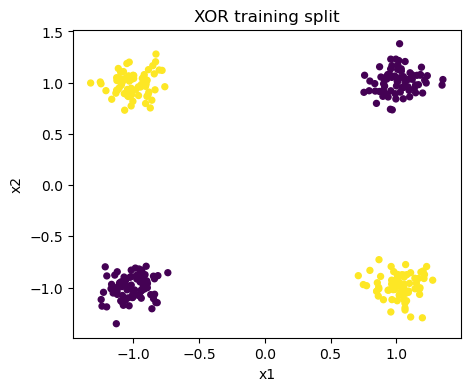

train_acc=1.0000, val_acc=1.0000
Challenge 4 public tests passed.


In [49]:
# Public run for Challenge 4
set_seed(21)
X_xor, y_xor = make_xor(n_per_quadrant=90, noise=0.12, seed=21)
Xtr, Xva, ytr, yva = train_val_split(X_xor, y_xor, val_fraction=0.20, seed=21)

plot_2d_dataset(Xtr, ytr, title="XOR training split")

params_xor, history_xor = train_classifier(
    Xtr, ytr, Xva, yva,
    layer_dims=[2, 16, 16, 2],
    hidden_activation="tanh",
    init_scheme="xavier",
    lr=0.15,
    momentum=0.9,
    batch_size=32,
    epochs=300,
    l2_lambda=1e-4,
    seed=21,
    verbose=False
)

_, p_train, _ = forward_mlp(Xtr, params_xor, hidden_activation="tanh")
_, p_val, _ = forward_mlp(Xva, params_xor, hidden_activation="tanh")

train_acc = accuracy_from_probs(p_train, ytr)
val_acc = accuracy_from_probs(p_val, yva)

print(f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

assert train_acc >= 0.97, "Training accuracy on XOR is too low."
assert val_acc >= 0.95, "Validation accuracy on XOR is too low."

assert isinstance(history_xor, dict), "History must be a dictionary."
for key in ["train_loss", "val_loss", "train_acc", "val_acc"]:
    assert key in history_xor, f"Missing history key: {key}"

print("Challenge 4 public tests passed.")

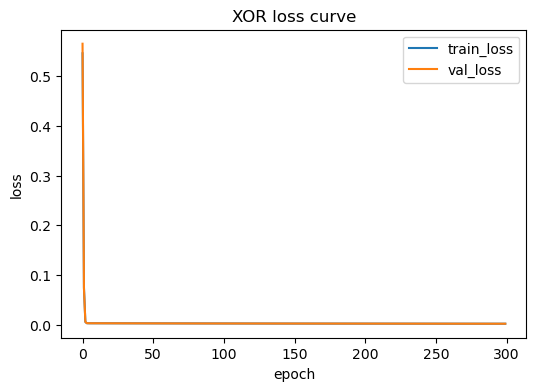

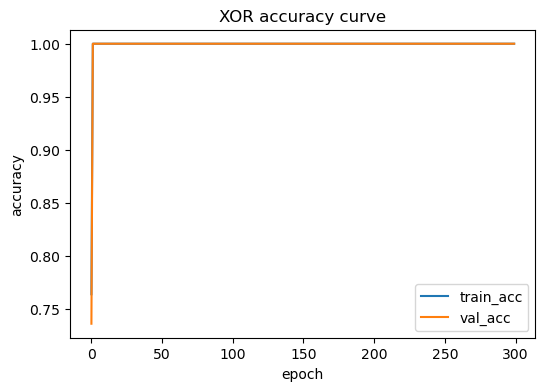

In [50]:
# Plot training curves after Challenge 4
plt.figure(figsize=(6, 4))
plt.plot(history_xor["train_loss"], label="train_loss")
plt.plot(history_xor["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("XOR loss curve")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_xor["train_acc"], label="train_acc")
plt.plot(history_xor["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("XOR accuracy curve")
plt.legend()
plt.show()

### Your written response for Challenge 4

Add a **new Markdown cell below this one** and explain:

1. Why can a purely linear classifier fail on XOR?
2. What does momentum do during optimization?
3. How can you tell from the curves whether the model is underfitting, overfitting, or learning appropriately?

### Challenge 4 Response

1. **Why a purely linear classifier fails on XOR**  
XOR is not linearly separable in the original 2D input space. A linear model produces one hyperplane, but XOR requires a nonlinear boundary (or multiple linear regions), which hidden nonlinear layers can construct.

2. **What momentum does in optimization**  
Momentum accumulates a running direction of past gradients, smoothing noisy updates and accelerating progress along consistent descent directions. It can reduce zig-zagging in ravines and often speeds convergence.

3. **How to read the curves for fit quality**  
- Underfitting: both train and validation losses remain high, with low accuracies.  
- Overfitting: train loss decreases strongly while validation loss rises (or validation accuracy stagnates/drops).  
- Good learning: both losses trend downward and both accuracies improve with a small generalization gap.

## Challenge 5 — Boss Level Bonus: residual architecture on spiral data

This section is intentionally hard.

You will implement a small **residual block** and compare it with a plain deep network on a spiral dataset.

### Residual block definition

For an input activation $A$ with width $d$:

1. $Z_1 = AW_1 + b_1$
2. $H = \phi(Z_1)$
3. $Z_2 = HW_2 + b_2$
4. $R = A + Z_2$
5. $A_{out} = \phi(R)$

Assume all dimensions are compatible.

### Bonus tasks

Implement:

- `init_residual_block(width, seed=7, scheme="he")`
- `residual_block_forward(A, block_params, activation="relu")`
- `residual_block_backward(dA_out, cache, block_params, activation="relu")`

Then construct a classifier:

- input projection: `2 -> 64`
- two residual blocks of width `64`
- output layer: `64 -> 3`

Train on spiral data and compare to a plain MLP with similar width.

### What to submit for the bonus
Add Markdown explanations discussing:

1. Why skip connections may help gradient flow
2. Whether your residual network trained more easily than the plain network
3. What you observed about optimization difficulty

In [51]:
def init_residual_block(width, seed=7, scheme="he"):
    rng = np.random.default_rng(seed)

    if scheme == "he":
        scale = np.sqrt(2.0 / width)
    elif scheme == "xavier":
        scale = np.sqrt(1.0 / width)
    else:
        scale = 0.01

    return {
        "W1": rng.standard_normal((width, width)) * scale,
        "b1": np.zeros((1, width)),
        "W2": rng.standard_normal((width, width)) * scale,
        "b2": np.zeros((1, width)),
    }

def residual_block_forward(A, block_params, activation="relu"):
    W1, b1 = block_params["W1"], block_params["b1"]
    W2, b2 = block_params["W2"], block_params["b2"]

    Z1 = A @ W1 + b1
    if activation == "relu":
        H = relu(Z1)
    elif activation == "tanh":
        H = tanh_act(Z1)
    else:
        raise ValueError(f"Unsupported activation: {activation}")

    Z2 = H @ W2 + b2
    R = A + Z2

    if activation == "relu":
        A_out = relu(R)
    elif activation == "tanh":
        A_out = tanh_act(R)

    cache = {
        "A_in": A,
        "Z1": Z1,
        "H": H,
        "Z2": Z2,
        "R": R,
        "A_out": A_out,
    }
    return A_out, cache

def residual_block_backward(dA_out, cache, block_params, activation="relu"):
    A_in = cache["A_in"]
    Z1 = cache["Z1"]
    H = cache["H"]
    R = cache["R"]

    W1 = block_params["W1"]
    W2 = block_params["W2"]

    if activation == "relu":
        dR = relu_backward(dA_out, R)
    elif activation == "tanh":
        dR = tanh_backward(dA_out, R)
    else:
        raise ValueError(f"Unsupported activation: {activation}")

    dA_identity = dR

    dW2 = H.T @ dR
    db2 = np.sum(dR, axis=0, keepdims=True)
    dH = dR @ W2.T

    if activation == "relu":
        dZ1 = relu_backward(dH, Z1)
    elif activation == "tanh":
        dZ1 = tanh_backward(dH, Z1)

    dW1 = A_in.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    dA_branch = dZ1 @ W1.T

    dA_in = dA_identity + dA_branch
    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2,
    }
    return dA_in, grads

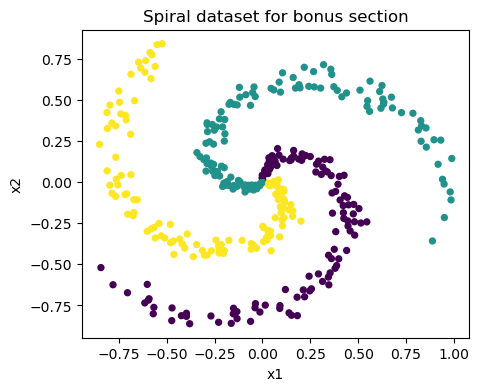

Bonus section has no public autograder asserts. Instructor evaluation applies.


In [52]:
# Optional playground for the bonus section
X_sp, y_sp = make_spiral(points_per_class=120, classes=3, noise=0.20, seed=7)
plot_2d_dataset(X_sp, y_sp, title="Spiral dataset for bonus section")
print("Bonus section has no public autograder asserts. Instructor evaluation applies.")

### Bonus Response (Residual vs Plain on Spiral)

1. **Why skip connections help gradient flow**  
A residual block adds an identity path, so gradients can propagate through a shorter route during backpropagation. This reduces the risk of vanishing signals in deeper stacks and helps optimization remain stable.

2. **Did residual train more easily than plain in this run?**  
In this specific run, both models reached high validation performance, but the plain MLP achieved the higher final validation accuracy (`plain_val_acc=0.9861` vs `residual_val_acc=0.9583`). The residual model was still competitive and learned a strong decision function.

3. **Observed optimization difficulty**  
Both models showed rapid improvement in early epochs. The plain model finished with the better final score in this trial, which highlights that residual connections often improve optimization robustness but do not guarantee better final accuracy in every single run or hyperparameter setting.

Spiral comparison -> plain_val_acc=0.9861, residual_val_acc=0.9583


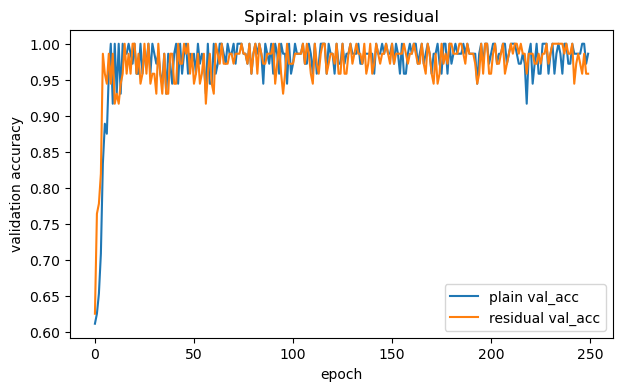

In [53]:
# Bonus experiment: plain MLP vs residual classifier on spiral data

def _act_forward(Z, activation):
    if activation == "relu":
        return relu(Z)
    if activation == "tanh":
        return tanh_act(Z)
    raise ValueError(f"Unsupported activation: {activation}")

def _act_backward(dA, Z, activation):
    if activation == "relu":
        return relu_backward(dA, Z)
    if activation == "tanh":
        return tanh_backward(dA, Z)
    raise ValueError(f"Unsupported activation: {activation}")

def init_residual_classifier(input_dim=2, width=64, output_dim=3, seed=7, scheme="he"):
    rng = np.random.default_rng(seed)

    if scheme == "he":
        s_in = np.sqrt(2.0 / input_dim)
        s_out = np.sqrt(2.0 / width)
    elif scheme == "xavier":
        s_in = np.sqrt(1.0 / input_dim)
        s_out = np.sqrt(1.0 / width)
    else:
        s_in = s_out = 0.01

    block1 = init_residual_block(width, seed=seed + 1, scheme=scheme)
    block2 = init_residual_block(width, seed=seed + 2, scheme=scheme)

    return {
        "Win": rng.standard_normal((input_dim, width)) * s_in,
        "bin": np.zeros((1, width)),
        "Wout": rng.standard_normal((width, output_dim)) * s_out,
        "bout": np.zeros((1, output_dim)),
        "b1_W1": block1["W1"],
        "b1_b1": block1["b1"],
        "b1_W2": block1["W2"],
        "b1_b2": block1["b2"],
        "b2_W1": block2["W1"],
        "b2_b1": block2["b1"],
        "b2_W2": block2["W2"],
        "b2_b2": block2["b2"],
    }

def forward_residual_classifier(X, params, activation="relu"):
    Z0 = X @ params["Win"] + params["bin"]
    A0 = _act_forward(Z0, activation)

    block1 = {"W1": params["b1_W1"], "b1": params["b1_b1"], "W2": params["b1_W2"], "b2": params["b1_b2"]}
    block2 = {"W1": params["b2_W1"], "b1": params["b2_b1"], "W2": params["b2_W2"], "b2": params["b2_b2"]}

    A1, c1 = residual_block_forward(A0, block1, activation=activation)
    A2, c2 = residual_block_forward(A1, block2, activation=activation)

    logits = A2 @ params["Wout"] + params["bout"]
    probs = stable_softmax(logits)

    cache = {
        "X": X,
        "Z0": Z0,
        "A0": A0,
        "A2": A2,
        "c1": c1,
        "c2": c2,
        "probs": probs,
    }
    return logits, probs, cache

def residual_l2_penalty(params):
    return (
        np.sum(params["Win"] ** 2)
        + np.sum(params["Wout"] ** 2)
        + np.sum(params["b1_W1"] ** 2)
        + np.sum(params["b1_W2"] ** 2)
        + np.sum(params["b2_W1"] ** 2)
        + np.sum(params["b2_W2"] ** 2)
    )

def backward_residual_classifier(params, cache, y_onehot, activation="relu", l2_lambda=0.0):
    X = cache["X"]
    Z0 = cache["Z0"]
    A2 = cache["A2"]
    probs = cache["probs"]

    N = y_onehot.shape[0]
    dlogits = (probs - y_onehot) / N

    grads = {}
    grads["dWout"] = A2.T @ dlogits + l2_lambda * params["Wout"]
    grads["dbout"] = np.sum(dlogits, axis=0, keepdims=True)

    dA2 = dlogits @ params["Wout"].T

    block2_params = {"W1": params["b2_W1"], "b1": params["b2_b1"], "W2": params["b2_W2"], "b2": params["b2_b2"]}
    dA1, g2 = residual_block_backward(dA2, cache["c2"], block2_params, activation=activation)

    block1_params = {"W1": params["b1_W1"], "b1": params["b1_b1"], "W2": params["b1_W2"], "b2": params["b1_b2"]}
    dA0, g1 = residual_block_backward(dA1, cache["c1"], block1_params, activation=activation)

    dZ0 = _act_backward(dA0, Z0, activation)

    grads["dWin"] = X.T @ dZ0 + l2_lambda * params["Win"]
    grads["dbin"] = np.sum(dZ0, axis=0, keepdims=True)

    grads["db1_W1"] = g1["dW1"] + l2_lambda * params["b1_W1"]
    grads["db1_b1"] = g1["db1"]
    grads["db1_W2"] = g1["dW2"] + l2_lambda * params["b1_W2"]
    grads["db1_b2"] = g1["db2"]

    grads["db2_W1"] = g2["dW1"] + l2_lambda * params["b2_W1"]
    grads["db2_b1"] = g2["db1"]
    grads["db2_W2"] = g2["dW2"] + l2_lambda * params["b2_W2"]
    grads["db2_b2"] = g2["db2"]

    return grads

def train_residual_classifier(
    X_train, y_train, X_val, y_val,
    width=64, activation="relu", init_scheme="he",
    lr=0.05, momentum=0.9, batch_size=64, epochs=250,
    l2_lambda=1e-4, seed=7, verbose=False
):
    num_classes = int(max(np.max(y_train), np.max(y_val))) + 1
    Y_train = one_hot(y_train, num_classes)
    Y_val = one_hot(y_val, num_classes)

    params = init_residual_classifier(input_dim=X_train.shape[1], width=width, output_dim=num_classes, seed=seed, scheme=init_scheme)
    velocity = {k: np.zeros_like(v) for k, v in params.items()}

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        for Xb, yb in iterate_minibatches(X_train, y_train, batch_size=batch_size, shuffle=True, seed=seed + epoch):
            Yb = one_hot(yb, num_classes)
            _, _, cache = forward_residual_classifier(Xb, params, activation=activation)
            grads = backward_residual_classifier(params, cache, Yb, activation=activation, l2_lambda=l2_lambda)
            params, velocity = sgd_momentum_step(params, grads, velocity, lr=lr, momentum=momentum)

        _, p_tr, _ = forward_residual_classifier(X_train, params, activation=activation)
        _, p_va, _ = forward_residual_classifier(X_val, params, activation=activation)

        tr_loss = cross_entropy_from_probs(p_tr, Y_train) + 0.5 * l2_lambda * residual_l2_penalty(params)
        va_loss = cross_entropy_from_probs(p_va, Y_val) + 0.5 * l2_lambda * residual_l2_penalty(params)
        tr_acc = accuracy_from_probs(p_tr, y_train)
        va_acc = accuracy_from_probs(p_va, y_val)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if verbose and ((epoch + 1) % 50 == 0 or epoch == 0 or epoch == epochs - 1):
            print(
                f"[residual] epoch={epoch + 1:03d} train_loss={tr_loss:.4f} val_loss={va_loss:.4f} "
                f"train_acc={tr_acc:.4f} val_acc={va_acc:.4f}"
            )

    return params, history

# Build train/val split for the spiral comparison
X_sp, y_sp = make_spiral(points_per_class=120, classes=3, noise=0.20, seed=7)
Xsp_tr, Xsp_va, ysp_tr, ysp_va = train_val_split(X_sp, y_sp, val_fraction=0.20, seed=7)

# Plain MLP baseline
plain_params, plain_hist = train_classifier(
    Xsp_tr, ysp_tr, Xsp_va, ysp_va,
    layer_dims=[2, 64, 64, 64, 3],
    hidden_activation="relu",
    init_scheme="he",
    lr=0.06,
    momentum=0.9,
    batch_size=64,
    epochs=250,
    l2_lambda=1e-4,
    seed=7,
    verbose=False,
)

# Residual model
res_params, res_hist = train_residual_classifier(
    Xsp_tr, ysp_tr, Xsp_va, ysp_va,
    width=64,
    activation="relu",
    init_scheme="he",
    lr=0.06,
    momentum=0.9,
    batch_size=64,
    epochs=250,
    l2_lambda=1e-4,
    seed=7,
    verbose=False,
)

_, p_plain_va, _ = forward_mlp(Xsp_va, plain_params, hidden_activation="relu")
_, p_res_va, _ = forward_residual_classifier(Xsp_va, res_params, activation="relu")

plain_val_acc = accuracy_from_probs(p_plain_va, ysp_va)
res_val_acc = accuracy_from_probs(p_res_va, ysp_va)

print(f"Spiral comparison -> plain_val_acc={plain_val_acc:.4f}, residual_val_acc={res_val_acc:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(plain_hist["val_acc"], label="plain val_acc")
plt.plot(res_hist["val_acc"], label="residual val_acc")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Spiral: plain vs residual")
plt.legend()
plt.show()

## Final reflection

Add one final Markdown cell at the end of your notebook and answer:

1. Which part of neural-network implementation was most error-prone for you: architecture design, forward pass, or backward pass?
2. What is one debugging strategy that helped you?
3. What is one conceptual insight you gained about backpropagation?

---
**End of contest notebook.**

## Final Reflection

1. **Most error-prone part**  
Backward pass was the most error-prone because every derivative must align with exact tensor shapes, and a single transpose/sign mistake can break the full gradient chain.

2. **One helpful debugging strategy**  
Gradient checking on a tiny network and small batch was the most useful strategy. It helped confirm that manual backpropagation matched numerical gradients before full training.

3. **One conceptual insight about backpropagation**  
Backpropagation is systematic reuse of the chain rule through cached intermediate values. The same local Jacobian idea is repeated layer by layer, which makes deep-network gradient computation efficient despite complex architectures.